<a href="https://colab.research.google.com/github/PriyaVerma06/EDA-IPL/blob/fix-E5/fix_E5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# issue #6

In [3]:
# 1. Setup and Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 2. Load Data

matches = pd.read_csv("https://raw.githubusercontent.com/PriyaVerma06/EDA-IPL/main/data/matches.csv")
deliveries = pd.read_csv("https://raw.githubusercontent.com/PriyaVerma06/EDA-IPL/main/data/deliveries.csv")

In [6]:
# 3. Filter 1st Innings Only

first_innings = deliveries[deliveries["inning"] == 1]

In [8]:
# 4. Compute Total Runs per Match per Team

# total_runs = batsman_runs + extra_runs
first_innings["total_runs"] = first_innings["batsman_runs"] + first_innings["extra_runs"]

innings_score = first_innings.groupby(
    ["match_id", "batting_team"]
)["total_runs"].sum().reset_index()

# Rename for clarity
innings_score.rename(columns={"total_runs": "first_innings_score"}, inplace=True)


/tmp/ipykernel_3629/2918464221.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_innings["total_runs"] = first_innings["batsman_runs"] + first_innings["extra_runs"]


In [9]:
# 5. Identify Match Type (Regular vs Playoff)

# Playoff matches usually have names like "Qualifier", "Eliminator", "Final"

matches["match_type"] = matches["match_type"].fillna("League")

# If dataset doesn't have match_type column, fallback:
if "match_type" not in matches.columns:
    matches["match_type"] = matches["stage"].apply(
        lambda x: "Playoff" if x in ["Qualifier", "Eliminator", "Final"] else "League"
    )

# Simplify labels
matches["match_category"] = matches["match_type"].apply(
    lambda x: "Playoff" if "Final" in str(x) or "Qualifier" in str(x) or "Eliminator" in str(x)
    else "Regular"
)

In [10]:
# 6. Merge with Matches

merged = pd.merge(
    innings_score,
    matches[["id", "match_category"]],
    left_on="match_id",
    right_on="id",
    how="left"
)


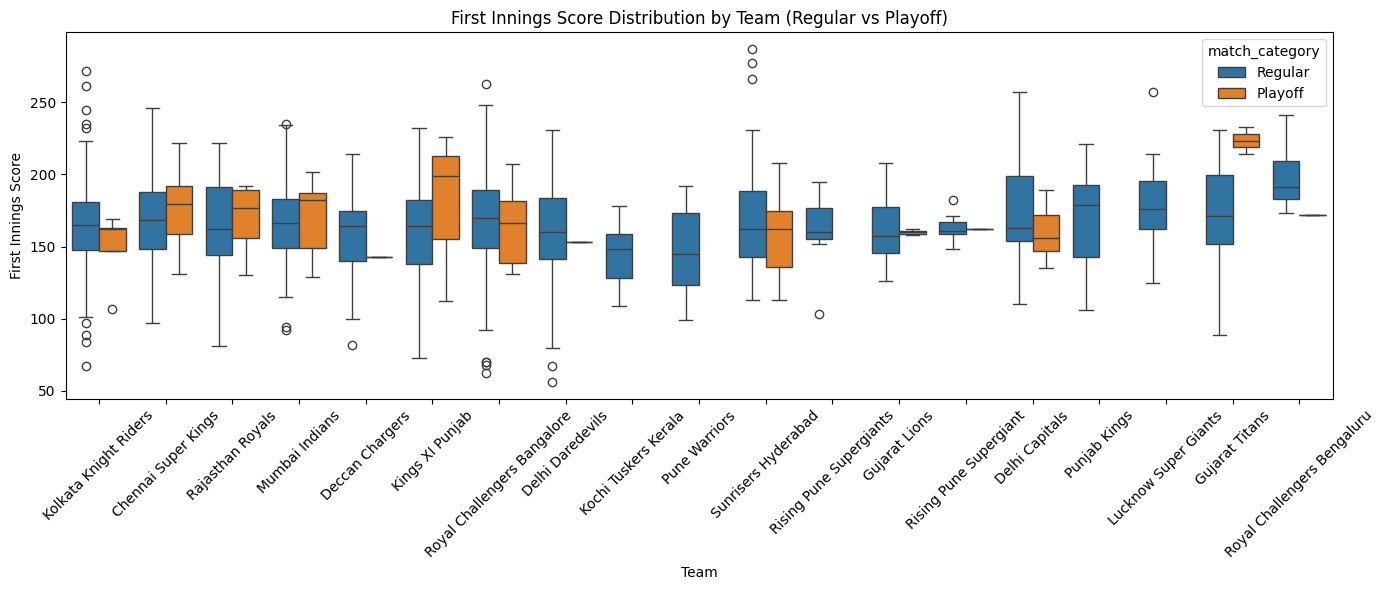

In [11]:
# 7. Visualization (Boxplot)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=merged,
    x="batting_team",
    y="first_innings_score",
    hue="match_category"
)

plt.xticks(rotation=45)
plt.title("First Innings Score Distribution by Team (Regular vs Playoff)")
plt.xlabel("Team")
plt.ylabel("First Innings Score")

plt.tight_layout()
plt.show()